In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('IRIS.csv')

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [6]:
import matplotlib.pyplot as plt

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


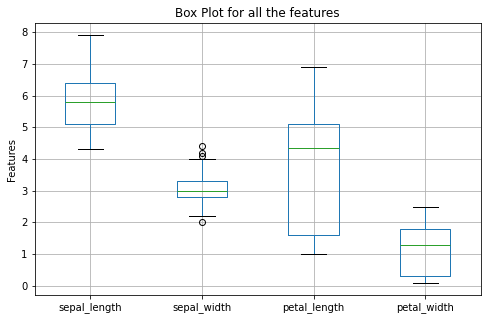

In [7]:
plt.figure(figsize = (8, 5))
df.boxplot()
plt.title('Box Plot for all the features')
plt.ylabel('Features')
plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

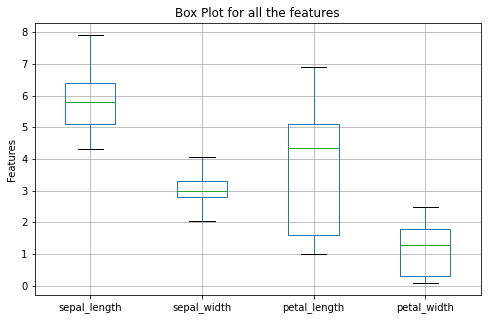

In [9]:
plt.figure(figsize = (8, 5))
df.boxplot()
plt.title('Box Plot for all the features')
plt.ylabel('Features')
plt.show()

In [10]:
X = df.drop('species', axis = 1)
y = df['species']

In [11]:
from sklearn.model_selection import train_test_split
import math

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
priors = y_train.value_counts(normalize = True)

In [14]:
priors

species
Iris-versicolor    0.341667
Iris-setosa        0.333333
Iris-virginica     0.325000
Name: proportion, dtype: float64

In [15]:
X_train.shape

(120, 4)

In [16]:
X_test.shape

(30, 4)

In [17]:
y_train.shape

(120,)

In [18]:
y_test.shape

(30,)

In [19]:
train_df = pd.concat([X_train, y_train], axis = 1)
stats = train_df.groupby('species').agg(['mean', 'var'])
stats

sepal_length           sepal_width           petal_length  \
                        mean       var        mean       var         mean   
species                                                                     
Iris-setosa         4.990000  0.127077    3.426250  0.137691     1.452500   
Iris-versicolor     5.919512  0.294110    2.771951  0.100756     4.241463   
Iris-virginica      6.533333  0.427544    2.966667  0.101754     5.520513   

                          petal_width            
                      var        mean       var  
species                                          
Iris-setosa      0.033840    0.242500  0.011737  
Iris-versicolor  0.231488    1.321951  0.042256  
Iris-virginica   0.293252    2.000000  0.084211

In [20]:
def calculate_likelihood(X, mean, var):
    eps = 1e-9
    exponent = math.exp(-((X - mean)**2) / (2 * var + eps))
    return (1 / (math.sqrt(2 * math.pi * var + eps))) * exponent

In [21]:
def predict_species(row):
    probabilities = {}
    for species in priors.index:
        prior = priors[species]
        likelihood = 1
        for feature in X.columns:
            mean = stats.loc[species, (feature, 'mean')]
            var = stats.loc[species, (feature, 'var')]
            likelihood *= calculate_likelihood(row[feature], mean, var)
        probabilities[species] = likelihood * prior
    return max(probabilities, key=probabilities.get)

In [22]:
y_pred = X_test.apply(predict_species, axis=1)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of manual Naive Bayes: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy of manual Naive Bayes: 100.00%

Detailed Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [24]:
from sklearn.metrics import confusion_matrix

In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [26]:
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"Accuracy: {accuracy}\nError Rate: {error_rate} \nPrecision: {precision}\nRecall: {recall}")

Accuracy: 1.0
Error Rate: 0.0 
Precision: 1.0
Recall: 1.0


***With using sklearn***

In [27]:
from sklearn.naive_bayes import GaussianNB

In [28]:
model = GaussianNB()

model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy of manual Naive Bayes: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_sklearn))

Accuracy of manual Naive Bayes: 100.00%

Detailed Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [30]:
cm = confusion_matrix(y_test, y_pred_sklearn)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [31]:
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"Accuracy: {accuracy}\nError Rate: {error_rate} \nPrecision: {precision}\nRecall: {recall}")

Accuracy: 1.0
Error Rate: 0.0 
Precision: 1.0
Recall: 1.0
